# Project 4 — Supply Chain & Inventory Optimization Analytics

**Tools:** Python, Pandas, NumPy, Matplotlib

### Project objectives
- Understand supply-chain data quality
- Analyze sales, revenue, cost and profit
- Analyze inventory, reorder points and stockouts
- Compare warehouses, suppliers, regions and SKUs
- Measure promotion performance
- Compare actual demand with demand forecasts
- Identify high-risk inventory

> This notebook is designed for the uploaded `supply_chain_dataset1(1).csv` file and includes defensive checks so it can run even when some optional columns are unavailable.


## 1. Import Libraries and Load Dataset

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 100)

# Automatically locate the uploaded dataset
possible_paths = [
    Path("supply_chain_dataset1.csv"),
    Path("/mnt/data/supply_chain_dataset1.csv")
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Put 'supply_chain_dataset1.csv' in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")


Dataset loaded successfully: supply_chain_dataset1.csv
Rows: 91,250
Columns: 15


## 2. Dataset Overview

In [2]:
display(df.head())
display(df.tail())
print("Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
91245,2024-12-26,SKU_50,WH_5,SUP_10,South,17,352,7,283,0,6.65,9.6,0,0,19.82
91246,2024-12-27,SKU_50,WH_5,SUP_10,South,21,331,7,283,0,6.65,9.6,0,0,27.96
91247,2024-12-28,SKU_50,WH_5,SUP_10,East,17,314,7,283,0,6.65,9.6,0,0,22.13
91248,2024-12-29,SKU_50,WH_5,SUP_10,South,24,290,7,283,0,6.65,9.6,1,0,24.11
91249,2024-12-30,SKU_50,WH_5,SUP_10,West,15,275,7,283,0,6.65,9.6,1,0,20.19


Shape: (91250, 15)

Columns:
1. Date
2. SKU_ID
3. Warehouse_ID
4. Supplier_ID
5. Region
6. Units_Sold
7. Inventory_Level
8. Supplier_Lead_Time_Days
9. Reorder_Point
10. Order_Quantity
11. Unit_Cost
12. Unit_Price
13. Promotion_Flag
14. Stockout_Flag
15. Demand_Forecast


In [3]:
print("Data types:")
display(df.dtypes.to_frame("Data_Type"))

print("\nNumerical summary:")
display(df.describe(include=[np.number]).T)

print("\nCategorical summary:")
display(df.describe(include=["object"]).T)


Data types:


,Data_Type
Date,object
SKU_ID,object
Warehouse_ID,object
Supplier_ID,object
Region,object
Units_Sold,int64
Inventory_Level,int64
Supplier_Lead_Time_Days,int64
Reorder_Point,int64
Order_Quantity,int64



Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Units_Sold,91250.0,20.054564,9.068602,0.00,13.00,20.00,27.00,59.00
Inventory_Level,91250.0,471.522312,133.488002,168.00,370.00,461.00,564.00,990.00
Supplier_Lead_Time_Days,91250.0,7.984000,3.907929,2.00,4.00,8.00,11.00,14.00
Reorder_Point,91250.0,300.068000,54.879945,201.00,252.00,300.00,346.00,398.00
Order_Quantity,91250.0,19.272493,82.340831,0.00,0.00,0.00,0.00,499.00
Unit_Cost,91250.0,12.203320,4.574982,5.02,8.18,11.99,16.32,19.76
Unit_Price,91250.0,18.261800,7.121136,6.95,12.00,18.18,23.39,35.10
Promotion_Flag,91250.0,0.101589,0.302109,0.00,0.00,0.00,0.00,1.00
Stockout_Flag,91250.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
Demand_Forecast,91250.0,20.082033,9.503955,0.00,12.95,19.95,26.93,61.42



Categorical summary:


,count,unique,top,freq
Date,91250,365,2024-01-01,250
SKU_ID,91250,50,SKU_1,1825
Warehouse_ID,91250,5,WH_1,18250
Supplier_ID,91250,10,SUP_7,12410
Region,91250,4,North,22974


## 3. Data Quality Checks

In [4]:
# Missing values
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_pct
}).sort_values("Missing_Count", ascending=False)

display(missing_report)

# Duplicate rows
duplicate_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count:,}")

# Unique values
unique_report = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[c].nunique(dropna=True) for c in df.columns]
})

display(unique_report)


,Missing_Count,Missing_Percentage
Date,0,0.0
SKU_ID,0,0.0
Warehouse_ID,0,0.0
Supplier_ID,0,0.0
Region,0,0.0
Units_Sold,0,0.0
Inventory_Level,0,0.0
Supplier_Lead_Time_Days,0,0.0
Reorder_Point,0,0.0
Order_Quantity,0,0.0


Duplicate rows: 0


,Column,Unique_Values
0,Date,365
1,SKU_ID,50
2,Warehouse_ID,5
3,Supplier_ID,10
4,Region,4
5,Units_Sold,58
6,Inventory_Level,781
7,Supplier_Lead_Time_Days,13
8,Reorder_Point,142
9,Order_Quantity,301


## 4. Clean Column Names and Date

In [5]:
# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

# Convert Date when available
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    print("Date range:", df["Date"].min(), "to", df["Date"].max())

    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Month_Name"] = df["Date"].dt.month_name()
    df["Quarter"] = df["Date"].dt.quarter
    df["Day_Name"] = df["Date"].dt.day_name()
else:
    print("Date column not found; date-based analysis will be skipped.")

display(df.head())


Date range: 2024-01-01 00:00:00 to 2024-12-30 00:00:00


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast,Year,Month,Month_Name,Quarter,Day_Name
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52,2024,1,January,1,Monday
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63,2024,1,January,1,Tuesday
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62,2024,1,January,1,Wednesday
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43,2024,1,January,1,Thursday
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70,2024,1,January,1,Friday


## 5. Numeric Data Validation

In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

negative_report = pd.DataFrame({
    "Column": numeric_columns,
    "Negative_Values": [(df[c] < 0).sum() for c in numeric_columns]
})

display(negative_report)

# Flag columns: show available values
for flag_col in ["Promotion_Flag", "Stockout_Flag"]:
    if flag_col in df.columns:
        print(f"\n{flag_col} value counts:")
        display(df[flag_col].value_counts(dropna=False).to_frame("Count"))


,Column,Negative_Values
0,Units_Sold,0
1,Inventory_Level,0
2,Supplier_Lead_Time_Days,0
3,Reorder_Point,0
4,Order_Quantity,0
5,Unit_Cost,0
6,Unit_Price,0
7,Promotion_Flag,0
8,Stockout_Flag,0
9,Demand_Forecast,0



Promotion_Flag value counts:


,Count
Promotion_Flag,
0,81980
1,9270



Stockout_Flag value counts:


,Count
Stockout_Flag,
0,91250


## 6. Create Business Metrics

In [7]:
# Required-column helper
def require_columns(columns, purpose):
    missing = [c for c in columns if c not in df.columns]
    if missing:
        print(f"Skipped {purpose}: missing columns {missing}")
        return False
    return True

# Revenue
if require_columns(["Units_Sold", "Unit_Price"], "Revenue"):
    df["Revenue"] = df["Units_Sold"] * df["Unit_Price"]

# Total cost
if require_columns(["Units_Sold", "Unit_Cost"], "Total Cost"):
    df["Total_Cost"] = df["Units_Sold"] * df["Unit_Cost"]

# Profit
if require_columns(["Revenue", "Total_Cost"], "Profit"):
    df["Profit"] = df["Revenue"] - df["Total_Cost"]

# Profit margin
if require_columns(["Revenue", "Profit"], "Profit Margin"):
    df["Profit_Margin"] = np.where(
        df["Revenue"].ne(0),
        df["Profit"] / df["Revenue"] * 100,
        0
    )

# Inventory value
if require_columns(["Inventory_Level", "Unit_Cost"], "Inventory Value"):
    df["Inventory_Value"] = df["Inventory_Level"] * df["Unit_Cost"]

# Forecast error
if require_columns(["Units_Sold", "Demand_Forecast"], "Forecast Error"):
    df["Forecast_Error"] = df["Units_Sold"] - df["Demand_Forecast"]
    df["Absolute_Forecast_Error"] = df["Forecast_Error"].abs()

display(df.head())


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast,Year,Month,Month_Name,Quarter,Day_Name,Revenue,Total_Cost,Profit,Profit_Margin,Inventory_Value,Forecast_Error,Absolute_Forecast_Error
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52,2024,1,January,1,Monday,204.80,139.50,65.30,31.884766,8258.40,1.48,1.48
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63,2024,1,January,1,Tuesday,348.16,237.15,111.01,31.884766,8021.25,-1.63,1.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62,2024,1,January,1,Wednesday,716.80,488.25,228.55,31.884766,7533.00,-4.62,4.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43,2024,1,January,1,Thursday,491.52,334.80,156.72,31.884766,7198.20,4.57,4.57
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70,2024,1,January,1,Friday,430.08,292.95,137.13,31.884766,6905.25,2.30,2.30


## 7. Inventory Status and Risk

In [8]:
if require_columns(["Inventory_Level", "Reorder_Point"], "Inventory Status"):
    df["Inventory_Status"] = np.select(
        [
            df["Inventory_Level"] <= 0,
            df["Inventory_Level"] <= df["Reorder_Point"]
        ],
        [
            "Out of Stock",
            "Reorder Required"
        ],
        default="Healthy"
    )
    display(df["Inventory_Status"].value_counts().to_frame("Count"))

if require_columns(["Inventory_Level", "Demand_Forecast"], "Days of Inventory"):
    df["Days_of_Inventory"] = np.where(
        df["Demand_Forecast"] > 0,
        df["Inventory_Level"] / df["Demand_Forecast"],
        np.nan
    )

if require_columns(["Days_of_Inventory", "Supplier_Lead_Time_Days"], "Inventory Risk"):
    df["Inventory_Risk"] = np.select(
        [
            df["Days_of_Inventory"] < df["Supplier_Lead_Time_Days"],
            df["Days_of_Inventory"] < df["Supplier_Lead_Time_Days"] * 2
        ],
        [
            "High Risk",
            "Medium Risk"
        ],
        default="Low Risk"
    )
    display(df["Inventory_Risk"].value_counts().to_frame("Count"))


,Count
Inventory_Status,
Healthy,86209
Reorder Required,5041


,Count
Inventory_Risk,
Low Risk,67095
Medium Risk,19936
High Risk,4219


## 8. Overall KPIs

In [9]:
kpis = {}

if "Units_Sold" in df.columns:
    kpis["Total Units Sold"] = df["Units_Sold"].sum()

if "Revenue" in df.columns:
    kpis["Total Revenue"] = df["Revenue"].sum()

if "Total_Cost" in df.columns:
    kpis["Total Cost"] = df["Total_Cost"].sum()

if "Profit" in df.columns:
    kpis["Total Profit"] = df["Profit"].sum()

if "Inventory_Value" in df.columns:
    kpis["Inventory Value"] = df["Inventory_Value"].sum()

if "Stockout_Flag" in df.columns:
    kpis["Stockout Rate (%)"] = df["Stockout_Flag"].mean() * 100

if "Absolute_Forecast_Error" in df.columns:
    kpis["Mean Absolute Error"] = df["Absolute_Forecast_Error"].mean()

kpi_table = pd.DataFrame({"KPI": list(kpis.keys()), "Value": list(kpis.values())})
display(kpi_table)


,KPI,Value
0,Total Units Sold,1.829979e+06
1,Total Revenue,3.342634e+07
2,Total Cost,2.233814e+07
3,Total Profit,1.108820e+07
4,Inventory Value,5.252440e+08
5,Stockout Rate (%),0.000000e+00
6,Mean Absolute Error,2.379817e+00


## 9. Monthly Performance

,Date,Units_Sold,Revenue,Profit,Inventory_Value,Stockout_Flag
0,2024-01-01,176681,3224684.78,1071043.99,49996517.69,0
1,2024-02-01,197188,3596623.24,1192850.66,40639563.46,0
2,2024-03-01,231596,4232663.58,1403172.35,43349904.01,0
3,2024-04-01,223793,4089320.27,1356620.65,41610014.09,0
4,2024-05-01,210841,3851210.26,1277501.27,43446626.84,0
5,2024-06-01,170013,3100546.96,1027600.03,42109526.04,0
6,2024-07-01,134915,2470711.65,819433.81,44158154.41,0
7,2024-08-01,99019,1811864.31,600731.14,45110182.35,0
8,2024-09-01,76304,1385993.27,459880.22,43224896.31,0
9,2024-10-01,79599,1455408.84,483422.54,45088880.03,0


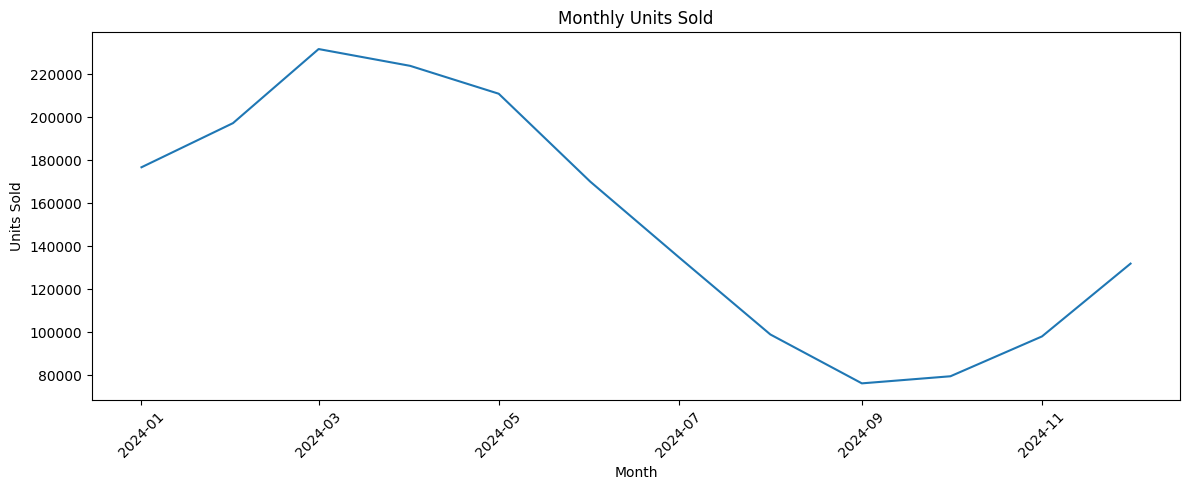

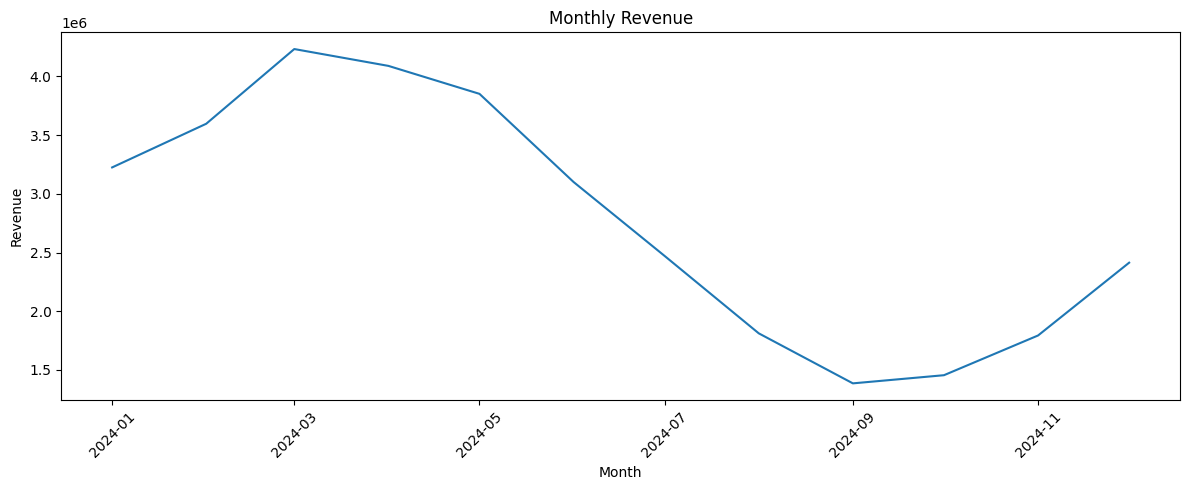

In [10]:
if "Date" in df.columns:
    monthly_agg = {"Units_Sold": "sum"}
    for c in ["Revenue", "Profit", "Inventory_Value", "Stockout_Flag"]:
        if c in df.columns:
            monthly_agg[c] = "sum"

    monthly = df.groupby(df["Date"].dt.to_period("M")).agg(monthly_agg).reset_index()
    monthly["Date"] = monthly["Date"].dt.to_timestamp()

    display(monthly.head(12))

    plt.figure(figsize=(12, 5))
    plt.plot(monthly["Date"], monthly["Units_Sold"])
    plt.title("Monthly Units Sold")
    plt.xlabel("Month")
    plt.ylabel("Units Sold")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    if "Revenue" in monthly.columns:
        plt.figure(figsize=(12, 5))
        plt.plot(monthly["Date"], monthly["Revenue"])
        plt.title("Monthly Revenue")
        plt.xlabel("Month")
        plt.ylabel("Revenue")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("Skipped monthly analysis because Date is unavailable.")


## 10. Regional Analysis

,Units_Sold,Revenue,Profit,Inventory_Value,Stockout_Flag
Region,,,,,
East,459961,8398382.40,2789524.01,1.321224e+08,0
North,459849,8411171.01,2788397.27,1.321490e+08,0
South,456954,8320450.82,2762288.19,1.305695e+08,0
West,453215,8296332.99,2747991.76,1.304031e+08,0


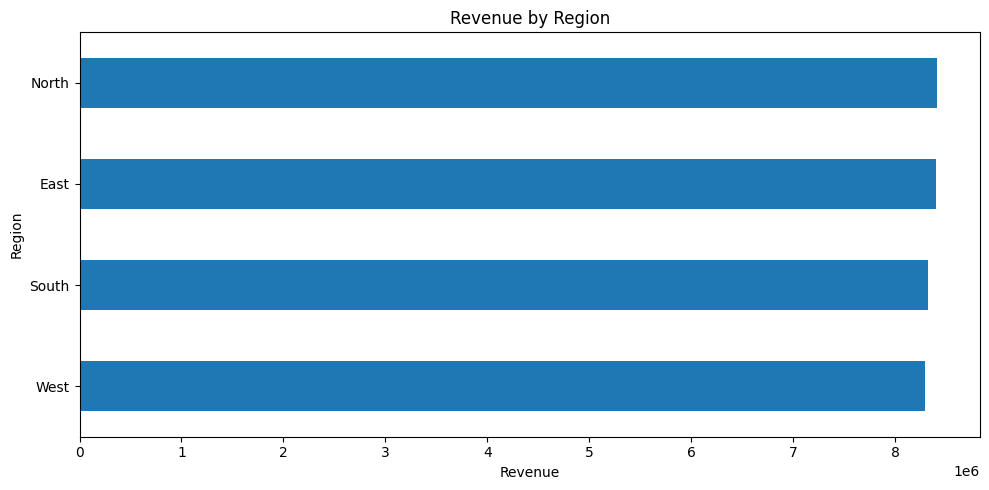

In [11]:
if "Region" in df.columns:
    agg = {"Units_Sold": "sum"}
    for c in ["Revenue", "Profit", "Inventory_Value", "Stockout_Flag"]:
        if c in df.columns:
            agg[c] = "sum"

    region_analysis = df.groupby("Region").agg(agg).sort_values(
        "Units_Sold", ascending=False
    )
    display(region_analysis)

    if "Revenue" in region_analysis.columns:
        plt.figure(figsize=(10, 5))
        region_analysis["Revenue"].sort_values().plot(kind="barh")
        plt.title("Revenue by Region")
        plt.xlabel("Revenue")
        plt.ylabel("Region")
        plt.tight_layout()
        plt.show()
else:
    print("Region column not found.")


## 11. Warehouse Analysis

,Units_Sold,Revenue,Profit,Inventory_Level,Inventory_Value,Stockout_Flag
Warehouse_ID,,,,,,
WH_2,366078,7395653.40,2405372.73,491.489644,1.213989e+08,0
WH_5,365114,6936392.83,2401057.94,467.116329,1.069279e+08,0
WH_3,366110,6478245.81,2193922.67,455.559068,9.715166e+07,0
WH_4,365775,6346286.39,2078071.72,477.390301,1.011034e+08,0
WH_1,366902,6269758.79,2009776.17,466.056219,9.866216e+07,0


,Stockout_Rate_Percent
Warehouse_ID,
WH_1,0.0
WH_2,0.0
WH_3,0.0
WH_4,0.0
WH_5,0.0


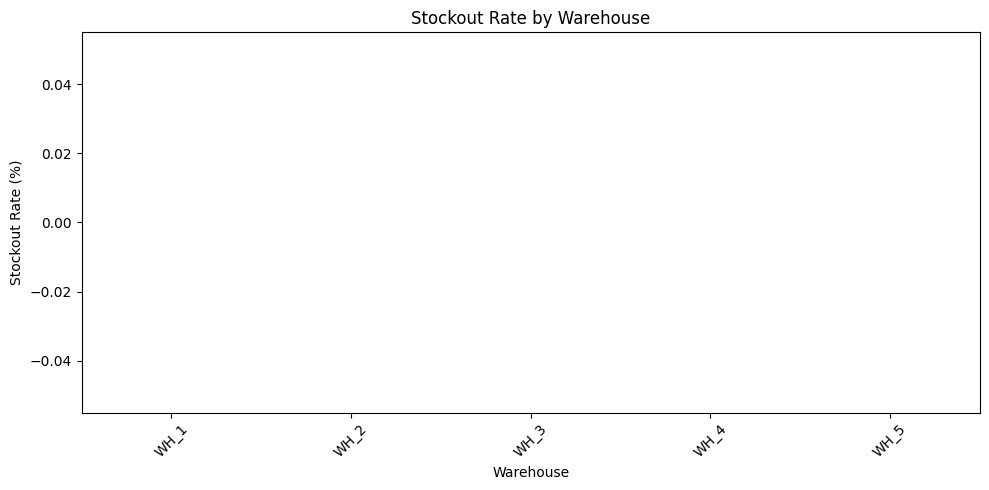

In [12]:
if "Warehouse_ID" in df.columns:
    agg = {"Units_Sold": "sum"}
    for c in ["Revenue", "Profit", "Inventory_Level", "Inventory_Value", "Stockout_Flag"]:
        if c in df.columns:
            agg[c] = "mean" if c == "Inventory_Level" else "sum"

    warehouse_analysis = df.groupby("Warehouse_ID").agg(agg)

    if "Revenue" in warehouse_analysis.columns:
        warehouse_analysis = warehouse_analysis.sort_values("Revenue", ascending=False)

    display(warehouse_analysis)

    if "Stockout_Flag" in df.columns:
        warehouse_stockout = (
            df.groupby("Warehouse_ID")["Stockout_Flag"]
              .mean()
              .mul(100)
              .sort_values(ascending=False)
        )
        display(warehouse_stockout.to_frame("Stockout_Rate_Percent"))

        plt.figure(figsize=(10, 5))
        warehouse_stockout.plot(kind="bar")
        plt.title("Stockout Rate by Warehouse")
        plt.xlabel("Warehouse")
        plt.ylabel("Stockout Rate (%)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("Warehouse_ID column not found.")


## 12. Supplier Analysis

In [13]:
if "Supplier_ID" in df.columns:
    agg = {}
    if "Supplier_Lead_Time_Days" in df.columns:
        agg["Supplier_Lead_Time_Days"] = "mean"
    if "Order_Quantity" in df.columns:
        agg["Order_Quantity"] = "sum"
    if "Units_Sold" in df.columns:
        agg["Units_Sold"] = "sum"
    if "Stockout_Flag" in df.columns:
        agg["Stockout_Flag"] = "sum"
    if "Inventory_Value" in df.columns:
        agg["Inventory_Value"] = "sum"

    if agg:
        supplier_analysis = df.groupby("Supplier_ID").agg(agg)
        if "Supplier_Lead_Time_Days" in supplier_analysis.columns:
            supplier_analysis = supplier_analysis.sort_values(
                "Supplier_Lead_Time_Days", ascending=False
            )
        display(supplier_analysis)
    else:
        print("No supplier metrics available.")
else:
    print("Supplier_ID column not found.")


,Supplier_Lead_Time_Days,Order_Quantity,Units_Sold,Stockout_Flag,Inventory_Value
Supplier_ID,,,,,
SUP_4,8.640000,176568,183147,0,57594320.83
SUP_8,8.500000,196023,205407,0,67744535.09
SUP_2,8.423077,184645,190999,0,50127302.52
SUP_3,8.260870,161721,168017,0,45340026.03
SUP_9,8.187500,112062,117259,0,29069391.27
SUP_1,8.107143,195080,204249,0,56591560.29
SUP_6,7.900000,141361,146684,0,44474872.45
SUP_7,7.558824,239283,248830,0,71298113.68
SUP_10,7.407407,189525,197242,0,58892568.37


## 13. SKU/Product Analysis

Top 10 SKUs:


,Units_Sold,Revenue,Profit,Inventory_Level,Inventory_Value,Stockout_Flag,Demand_Forecast
SKU_ID,,,,,,,
SKU_38,36739,1057641.51,368630.97,477.363288,16354739.83,0,36827.44
SKU_40,36443,923848.62,354456.86,472.634521,13607862.25,0,36572.86
SKU_11,36358,888870.07,333158.84,500.064658,13662728.38,0,36443.12
SKU_48,36597,846494.22,290867.82,484.007123,13714919.81,0,36706.92
SKU_31,36742,827241.09,282770.56,465.242740,12692518.80,0,37030.60
SKU_22,36646,794945.99,261633.79,457.368767,12185408.67,0,36769.94
SKU_46,36270,789467.78,260882.66,466.394521,12443873.53,0,36419.97
SKU_37,36730,772557.65,279719.70,465.055890,11429425.92,0,36837.39
SKU_4,36811,770679.65,265429.28,470.573151,11924966.98,0,36813.70


Bottom 10 SKUs:


,Units_Sold,Revenue,Profit,Inventory_Level,Inventory_Value,Stockout_Flag,Demand_Forecast
SKU_ID,,,,,,,
SKU_28,36481,577000.84,165751.75,481.093699,10096158.05,0,36483.19
SKU_45,36347,576849.88,159935.51,440.816438,8946441.20,0,36416.10
SKU_49,36479,553957.45,167156.49,447.672877,9023506.62,0,36414.08
SKU_42,36637,544829.43,172039.03,485.337534,8748259.28,0,36577.28
SKU_47,36912,538811.71,184386.46,514.666849,9035680.22,0,36880.77
SKU_41,36532,525021.08,176084.46,523.970411,8846135.64,0,36606.40
SKU_25,36590,504606.79,165338.66,467.837808,7906100.62,0,36593.59
SKU_14,36585,494097.50,127703.01,445.760548,7937447.92,0,36634.15
SKU_34,36537,453535.21,165917.89,445.990137,6352433.81,0,36696.94


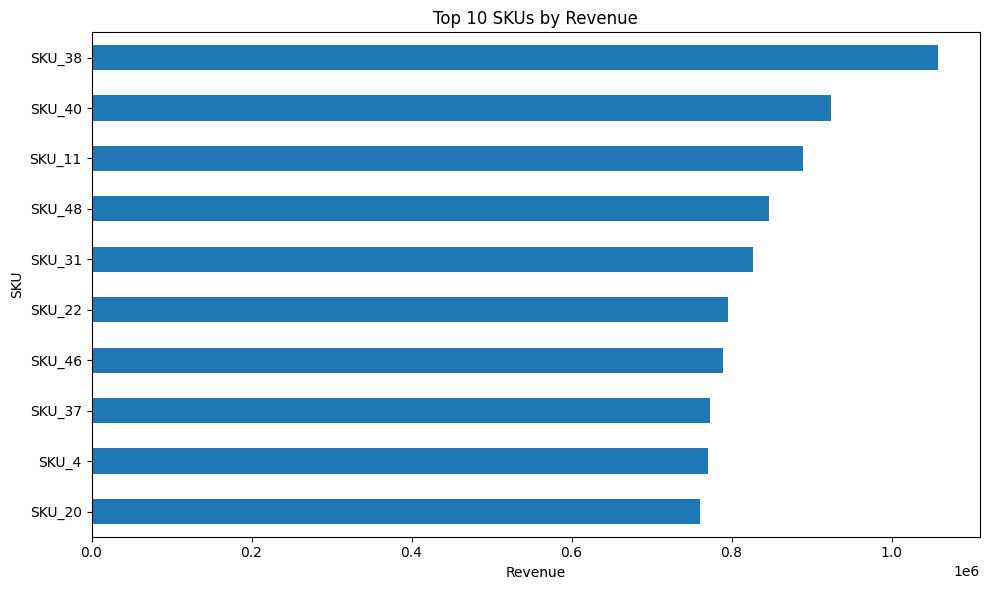

In [14]:
if "SKU_ID" in df.columns:
    agg = {"Units_Sold": "sum"}
    for c in ["Revenue", "Profit", "Inventory_Level", "Inventory_Value",
              "Stockout_Flag", "Demand_Forecast"]:
        if c in df.columns:
            agg[c] = "mean" if c == "Inventory_Level" else "sum"

    sku_analysis = df.groupby("SKU_ID").agg(agg)

    if "Revenue" in sku_analysis.columns:
        sku_analysis = sku_analysis.sort_values("Revenue", ascending=False)

    print("Top 10 SKUs:")
    display(sku_analysis.head(10))

    print("Bottom 10 SKUs:")
    display(sku_analysis.tail(10))

    if "Revenue" in sku_analysis.columns:
        top10 = sku_analysis.head(10).sort_values("Revenue")
        plt.figure(figsize=(10, 6))
        top10["Revenue"].plot(kind="barh")
        plt.title("Top 10 SKUs by Revenue")
        plt.xlabel("Revenue")
        plt.ylabel("SKU")
        plt.tight_layout()
        plt.show()
else:
    print("SKU_ID column not found.")


## 14. Promotion Analysis

In [15]:
if "Promotion_Flag" in df.columns:
    agg = {"Units_Sold": "mean"}
    if "Revenue" in df.columns:
        agg["Revenue"] = "sum"
    if "Profit" in df.columns:
        agg["Profit"] = "sum"

    promotion_analysis = df.groupby("Promotion_Flag").agg(agg)
    display(promotion_analysis)

    if 0 in promotion_analysis.index and 1 in promotion_analysis.index:
        print("\nPromotion impact:")
        print("Average Units Sold - No Promotion:",
              promotion_analysis.loc[0, "Units_Sold"])
        print("Average Units Sold - Promotion:",
              promotion_analysis.loc[1, "Units_Sold"])
else:
    print("Promotion_Flag column not found.")


,Units_Sold,Revenue,Profit
Promotion_Flag,,,
0,19.504977,29191354.87,9682150.07
1,24.914887,4234982.35,1406051.16



Promotion impact:
Average Units Sold - No Promotion: 19.504976823615515
Average Units Sold - Promotion: 24.914886731391586


## 15. Stockout Analysis

Total stockout records: 0
Stockout rate: 0.00%


,Stockout_Rate_Percent
Region,
East,0.0
North,0.0
South,0.0
West,0.0


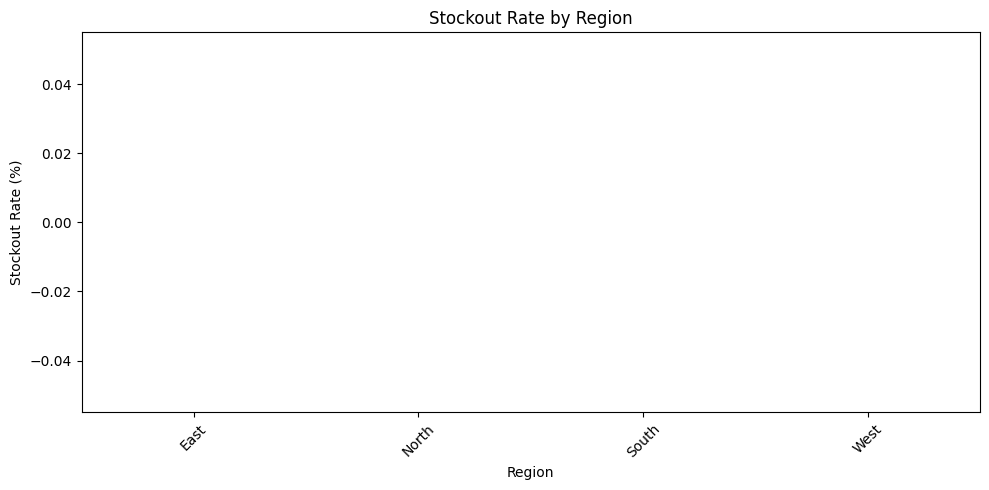

In [16]:
if "Stockout_Flag" in df.columns:
    total_stockouts = int(df["Stockout_Flag"].sum())
    stockout_rate = df["Stockout_Flag"].mean() * 100

    print(f"Total stockout records: {total_stockouts:,}")
    print(f"Stockout rate: {stockout_rate:.2f}%")

    if "Region" in df.columns:
        region_stockout = (
            df.groupby("Region")["Stockout_Flag"]
              .mean()
              .mul(100)
              .sort_values(ascending=False)
        )
        display(region_stockout.to_frame("Stockout_Rate_Percent"))

        plt.figure(figsize=(10, 5))
        region_stockout.plot(kind="bar")
        plt.title("Stockout Rate by Region")
        plt.xlabel("Region")
        plt.ylabel("Stockout Rate (%)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("Stockout_Flag column not found.")


## 16. Demand Forecast Accuracy

MAE: 2.38
MAPE: 16.32%
Forecast Accuracy (100 - MAPE): 83.68%


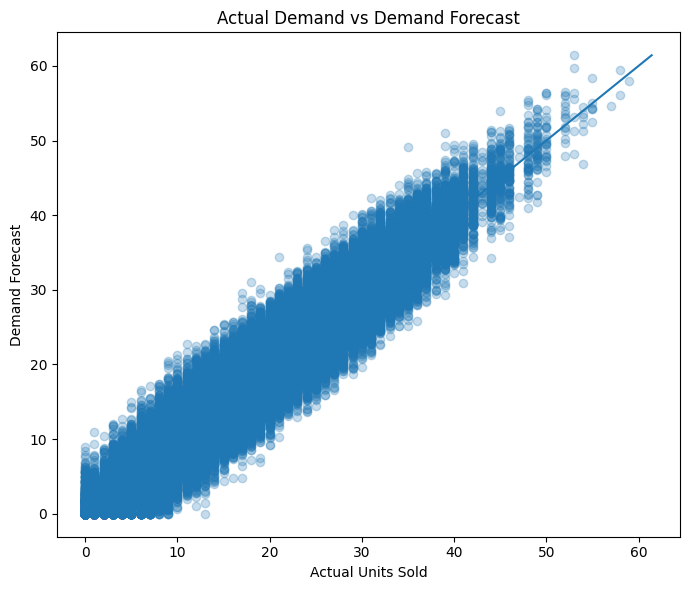

In [17]:
if require_columns(["Units_Sold", "Demand_Forecast"], "Forecast Accuracy"):
    actual = df["Units_Sold"]
    forecast = df["Demand_Forecast"]

    mae = (actual - forecast).abs().mean()

    # MAPE excluding zero actual-demand rows
    non_zero = actual != 0
    if non_zero.any():
        mape = (
            ((actual[non_zero] - forecast[non_zero]).abs()
             / actual[non_zero])
            .mean() * 100
        )
        forecast_accuracy = 100 - mape
    else:
        mape = np.nan
        forecast_accuracy = np.nan

    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Forecast Accuracy (100 - MAPE): {forecast_accuracy:.2f}%")

    # Actual vs forecast scatter
    plt.figure(figsize=(7, 6))
    plt.scatter(actual, forecast, alpha=0.25)
    min_val = min(actual.min(), forecast.min())
    max_val = max(actual.max(), forecast.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.title("Actual Demand vs Demand Forecast")
    plt.xlabel("Actual Units Sold")
    plt.ylabel("Demand Forecast")
    plt.tight_layout()
    plt.show()
else:
    print("Forecast columns unavailable.")


## 17. High-Risk Inventory

In [18]:
if "Inventory_Risk" in df.columns:
    high_risk = df[df["Inventory_Risk"] == "High Risk"].copy()

    print(f"High-risk records: {len(high_risk):,}")

    group_cols = [c for c in ["SKU_ID", "Warehouse_ID"] if c in high_risk.columns]

    if group_cols:
        agg = {}
        if "Days_of_Inventory" in high_risk.columns:
            agg["Days_of_Inventory"] = "mean"
        if "Supplier_Lead_Time_Days" in high_risk.columns:
            agg["Supplier_Lead_Time_Days"] = "mean"
        if "Stockout_Flag" in high_risk.columns:
            agg["Stockout_Flag"] = "sum"
        if "Units_Sold" in high_risk.columns:
            agg["Units_Sold"] = "sum"
        if "Inventory_Level" in high_risk.columns:
            agg["Inventory_Level"] = "mean"

        if agg:
            high_risk_summary = (
                high_risk.groupby(group_cols)
                .agg(agg)
                .sort_values(
                    "Stockout_Flag" if "Stockout_Flag" in agg else list(agg.keys())[0],
                    ascending=False
                )
            )
            display(high_risk_summary.head(20))
    else:
        display(high_risk.head(20))
else:
    print("Inventory risk could not be calculated.")


High-risk records: 4,219


Days_of_Inventory  Supplier_Lead_Time_Days  Stockout_Flag  Units_Sold  Inventory_Level
SKU_ID Warehouse_ID                                                                                        
SKU_1  WH_1                  12.039534                     14.0              0         926       431.192308
       WH_4                   8.375635                      9.0              0          39       363.000000
SKU_10 WH_1                  11.182670                     13.0              0         985       405.392857
       WH_2                   7.908057                     10.0              0         339       314.888889
       WH_3                   4.160762                      5.0              0          86       190.000000
       WH_4                  11.528703                     14.0              0        1485       372.574468
       WH_5                   7.689607                      9.0              0         721       256.500000
SKU_11 WH_3                  10.389083                     13.0              0         985       368.137931
SKU_12 WH_3                   5.379747                      6.0              0          42       221.000000
       WH_4                   9.127395                     12.0              0        1861       272.936508
SKU_13 WH_1                   7.395880                      9.0              0         799       266.217391
       WH_2                   9.361598                     11.0              0         593       364.750000
       WH_3                  12.067557                     14.0              0         889       410.888889
       WH_4                   8.216715                     10.0              0        1084       284.437500
SKU_14 WH_1                   8.962478                     11.0              0         997       297.225806
       WH_2                  10.952881                     14.0              0        2555       335.761905
       WH_4                   8.727563                     10.0              0         116       355.333333
       WH_5                   4.846169                      6.0              0          45       241.000000
SKU_15 WH_1                  11.192953                     13.0              0        1436       369.659091
       WH_3                   6.306783                      7.0              0         115       257.666667

## 18. Key Business Findings — Automatic Summary

In [19]:
print("=" * 70)
print("SUPPLY CHAIN ANALYTICS — KEY FINDINGS")
print("=" * 70)

if "Revenue" in df.columns:
    print(f"Total Revenue: {df['Revenue'].sum():,.2f}")

if "Profit" in df.columns:
    print(f"Total Profit: {df['Profit'].sum():,.2f}")

if "Units_Sold" in df.columns:
    print(f"Total Units Sold: {df['Units_Sold'].sum():,.0f}")

if "Inventory_Value" in df.columns:
    print(f"Inventory Value: {df['Inventory_Value'].sum():,.2f}")

if "Stockout_Flag" in df.columns:
    print(f"Stockout Rate: {df['Stockout_Flag'].mean() * 100:.2f}%")

if "Region" in df.columns and "Revenue" in df.columns:
    region_rev = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
    print(f"Top Revenue Region: {region_rev.index[0]}")

if "Warehouse_ID" in df.columns and "Revenue" in df.columns:
    wh_rev = df.groupby("Warehouse_ID")["Revenue"].sum().sort_values(ascending=False)
    print(f"Top Revenue Warehouse: {wh_rev.index[0]}")

if "SKU_ID" in df.columns and "Revenue" in df.columns:
    sku_rev = df.groupby("SKU_ID")["Revenue"].sum().sort_values(ascending=False)
    print(f"Top Revenue SKU: {sku_rev.index[0]}")

if "Supplier_ID" in df.columns and "Supplier_Lead_Time_Days" in df.columns:
    supplier_lt = df.groupby("Supplier_ID")["Supplier_Lead_Time_Days"].mean()
    print(f"Longest Average Supplier Lead Time: {supplier_lt.idxmax()} ({supplier_lt.max():.2f} days)")

print("=" * 70)


SUPPLY CHAIN ANALYTICS — KEY FINDINGS
Total Revenue: 33,426,337.22
Total Profit: 11,088,201.23
Total Units Sold: 1,829,979
Inventory Value: 525,243,991.12
Stockout Rate: 0.00%
Top Revenue Region: North
Top Revenue Warehouse: WH_2
Top Revenue SKU: SKU_38
Longest Average Supplier Lead Time: SUP_4 (8.64 days)


## 19. Export Clean Dataset

In [20]:
OUTPUT_PATH = Path("project4_supply_chain_cleaned.csv")

df.to_csv(OUTPUT_PATH, index=False)

print(f"Cleaned dataset exported successfully: {OUTPUT_PATH.resolve()}")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


Cleaned dataset exported successfully: C:\Users\Krish Bhalala\Documents\12 projects\4.Inventory Analytics\Python\project4_supply_chain_cleaned.csv
Final shape: 91,250 rows × 30 columns


## 20. Portfolio Conclusion

### Business questions answered
1. What are the overall sales, revenue and profit levels?
2. Which regions generate the most revenue?
3. Which warehouses have stronger or weaker performance?
4. Which suppliers have longer lead times?
5. Which SKUs generate the most revenue?
6. Where are stockouts concentrated?
7. How do promotions affect sales?
8. How accurate is demand forecasting?
9. Which inventory records are high risk?

### Recommended Power BI pages
- **Page 1:** Executive Overview
- **Page 2:** Inventory & Stockout Analysis
- **Page 3:** Supplier & Warehouse Performance
- **Page 4:** Demand & Forecast Analysis

**Next step:** Import `project4_supply_chain_cleaned.csv` into Power BI and build the four-page dashboard.
